In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 13:59:29,575	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [4]:
# ============================================================
# SETTINGS
# ============================================================

N_REALIZATIONS = 10

noise_levels = [0.01, 0.03, 0.05, 0.10]

MODEL_PARAM_COUNT = 7

In [5]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [6]:
# ============================================================
# TRUE MODEL
# ============================================================

true_parameters = [
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01,
    2,
    3e-1,
    5,
    0.1,
    1,
    0.1,
    0.1,
]

In [7]:
parameters_observational = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])


initial_condition = gaussian_sum_from_p(
    parameters_observational,
    ln_mbh_grid,
    n_gauss=3
)

In [8]:
# ============================================================
# FORWARD MODEL
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

true_accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

outputs_true = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        true_accretion_params
    )
)

true_final_data = outputs_true.n_final.copy()

In [9]:
initial_parameters = np.abs(np.random.randn(16))

# bounds = tuple([(0.001, 15) for _ in range(16)])  # 9 for gaussians, 7 for physical params

# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])

In [12]:
# ============================================================
# SINGLE REALIZATION
# ============================================================

def run_single_realization(noise_level, seed):

    # --------------------------------------------------------
    # noisy synthetic observations
    # --------------------------------------------------------

    target_data = add_noise_to_data(
        data=true_final_data,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=seed,
        noise_type="mixed"
    )

    # --------------------------------------------------------
    # inversion
    # --------------------------------------------------------

    result = ray.get(
        objective_function.optimizer.remote(
            bounds=bounds,
            target_data=target_data,
            weight_p=0.1,
            weight_theta=0.1,
            use_de=True,
            fast_mode=False,
        )
    )

    best_params = result.x

    # --------------------------------------------------------
    # recovered initial condition
    # --------------------------------------------------------

    gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]

    recovered_initial = gaussian_sum_from_p(
        gaussian_parameters,
        ln_mbh_grid,
        n_gauss=3
    )

    # --------------------------------------------------------
    # reconstruction metrics
    # --------------------------------------------------------

    metrics = {
        "noise_level": noise_level,
        "seed": seed,

        "nrmse_initial": nrmse_percent(
            initial_condition,
            recovered_initial,
            denom="mean"
        ),

        "smape_initial": smape_percent(
            initial_condition,
            recovered_initial
        ),

        "mape_initial": stabilized_mape_percent(
            initial_condition,
            recovered_initial
        ),
    }

    return metrics

In [13]:
# ============================================================
# MONTE CARLO LOOP
# ============================================================

all_results = []

for noise_level in noise_levels:

    print(f"\nNoise level = {noise_level:.2%}")

    for seed in range(N_REALIZATIONS):

        print(f"  realization {seed+1}/{N_REALIZATIONS}")

        metrics = run_single_realization(
            noise_level=noise_level,
            seed=seed
        )

        all_results.append(metrics)


Noise level = 1.00%
  realization 1/10
(ParametersRecovery pid=629985) Starting optimization ...
(ParametersRecovery pid=629985) Objective value: 1.563372e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.399234e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=629985) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=629985)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=629985) Objective value: 1.357843e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.348733e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.293168e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.278445e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.277212e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.267610e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.201902e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.165664e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.124937e+02 | Context: Minimum detected in annealing process
(

(ParametersRecovery pid=629985) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:230: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=629985)   normalization_model = np.log10(params_array[-n:] + epsilon)


(ParametersRecovery pid=629985) Objective value: 1.927786e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.880277e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.877287e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.872711e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.871467e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.870923e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.743708e+01 | Context: Detection occurred in local search
(ParametersRecovery pid=629985) Objective value: 1.729485e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 1.729415e+01 | Context: Minimum detected in annealing process
(Par

(ParametersRecovery pid=629985) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:56: RuntimeWarning: overflow encountered in exp
(ParametersRecovery pid=629985)   u = np.exp((alpha - 1) * x) * (tau_star / age) * \


(ParametersRecovery pid=629985) Objective value: 2.139101e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.138957e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.138947e+01 | Context: Detection occurred in local search
(ParametersRecovery pid=629985) Objective value: 2.136398e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.136191e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.126773e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.126468e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.124496e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=629985) Objective value: 2.124217e+01 | Context: Minimum detected in annealing process
(Par

In [19]:
# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(all_results)

print(df.head())

   noise_level  seed  nrmse_initial  smape_initial   mape_initial
0         0.01     0      48.063928      19.676670      17.819885
1         0.01     1      66.317724      30.613853      29.318249
2         0.01     2      48.749392      73.378083      49.672395
3         0.01     3     226.129815     171.711587  589431.163484
4         0.01     4      51.686442      98.516524      61.300373


In [20]:
df.to_csv("./results/monte_carlo_parameter_recover_results.csv", index=False)

In [21]:
df = pd.read_csv("./results/monte_carlo_parameter_recover_results.csv")

In [22]:
summary = (
    df.groupby("noise_level")
    .agg(
        {
            "nrmse_initial": ["mean", "std"],
            "smape_initial": ["mean", "std"],
            "mape_initial": ["mean", "std"],
        }
    )
)

print(summary)

            nrmse_initial            smape_initial              mape_initial  \
                     mean        std          mean        std           mean   
noise_level                                                                    
0.01            76.813050  59.777552     76.826529  43.401407  324551.279500   
0.03            56.313050  27.950767     60.269103  28.044260     559.671467   
0.05            77.962654  34.331675     85.997773  23.980206   25569.572573   
0.10            73.043321  32.174413     82.357300  22.498709  739317.522920   

                           
                      std  
noise_level                
0.01         8.397761e+05  
0.03         1.479725e+03  
0.05         7.886024e+04  
0.10         2.298880e+06  


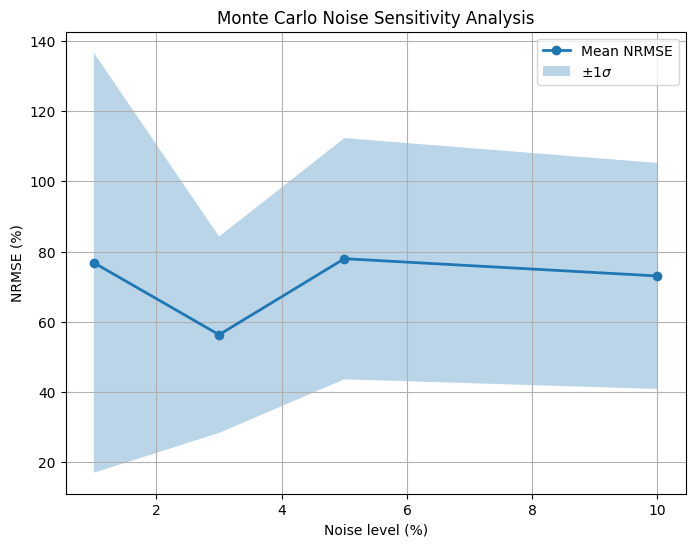

In [24]:
# ============================================================
# PLOT
# ============================================================

noise_percent = 100 * np.array(noise_levels)

mean_nrmse = (
    df.groupby("noise_level")["nrmse_initial"]
    .mean()
    .values
)

std_nrmse = (
    df.groupby("noise_level")["nrmse_initial"]
    .std()
    .values
)

plt.figure(figsize=(8, 6))

plt.plot(
    noise_percent,
    mean_nrmse,
    marker="o",
    linewidth=2,
    label="Mean NRMSE"
)

plt.fill_between(
    noise_percent,
    mean_nrmse - std_nrmse,
    mean_nrmse + std_nrmse,
    alpha=0.3,
    label=r"$\pm 1\sigma$"
)

plt.xlabel("Noise level (%)")
plt.ylabel("NRMSE (%)")

plt.title("Monte Carlo Noise Sensitivity Analysis")

plt.grid(True)
plt.legend()
plt.savefig("./images/monte_carlo_noise.png", dpi=300, bbox_inches="tight")

plt.show()